# 🔍 Feature Importance Explainer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/feature-importance/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/feature-importance/demo.ipynb)

> **"Stakeholders don't trust the model."** One importance number is easy to doubt. Three independent methods that *agree* is evidence.

This notebook scores every feature **three ways** and flags where they agree (trust it) vs. disagree (investigate):

1. Build a churn-style dataset with 3 real signals, 2 redundant columns, and 3 pure noise columns
2. Train a RandomForest
3. Compute **impurity**, **permutation**, and **drop-column** importance
4. Visualize them side by side
5. Deliver a **trusted / noise / review** verdict per feature

No SHAP dependency — runs anywhere.

## Step 1 — A dataset where we know the truth

We use `make_classification` to plant exactly **3 informative** features, **2 redundant** (linear combos of the informative ones), and **3 noise** features. Because we know which is which, we can judge whether each importance method actually recovers the truth.

In [1]:
from __future__ import annotations

from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

SEED = 42

X_arr, y_arr = make_classification(
    n_samples=1500, n_features=8, n_informative=3, n_redundant=2,
    n_repeated=0, n_classes=2, random_state=SEED, shuffle=False,
)
names = [
    "tenure_months", "monthly_spend", "support_tickets",  # informative
    "redundant_a", "redundant_b",                           # redundant
    "noise_login_hour", "noise_device_id", "noise_random",  # noise
]
X = pd.DataFrame(X_arr, columns=names)
y = pd.Series(y_arr, name="churned")
print(X.shape, "| churn rate:", round(y.mean(), 3))
X.head()

(1500, 8) | churn rate: 0.502


,tenure_months,monthly_spend,support_tickets,redundant_a,redundant_b,noise_login_hour,noise_device_id,noise_random
0,-2.055031,0.515593,0.475242,-1.583897,0.403599,0.742459,-0.637588,0.216683
1,-0.349714,-0.998455,1.174260,-1.727217,-0.579945,-0.303350,-0.218866,0.766243
2,-1.175859,-0.702026,0.231253,-1.541734,-0.765006,-1.040194,1.945195,-1.821086
3,-0.848670,-1.170166,-1.865660,-0.186366,-1.984108,-0.597668,0.370212,0.584314
4,-1.488884,-1.277464,0.539565,-2.376466,-1.256058,-0.100476,-0.057391,0.410550


## Step 2 — Train the model

A 200-tree RandomForest. We hold out 30% for honest scoring and report **ROC-AUC**.

In [2]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
model = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
model.fit(X_tr, y_tr)

def score(m, Xs, ys):
    return roc_auc_score(ys, m.predict_proba(Xs)[:, 1])

baseline = score(model, X_te, y_te)
print(f"Baseline test AUC: {baseline:.3f}")

Baseline test AUC: 0.989


## Step 3 — Method 1: Impurity importance

The tree's built-in `feature_importances_` — how much each feature reduced impurity across all splits. **Fast, but biased** toward high-cardinality features, and computed on *training* data so it can overstate noise.

In [3]:
impurity = pd.Series(model.feature_importances_, index=names)
impurity.sort_values(ascending=False).round(4)

tenure_months       0.3038
redundant_a         0.1986
support_tickets     0.1461
monthly_spend       0.1432
redundant_b         0.1270
noise_login_hour    0.0276
noise_device_id     0.0270
noise_random        0.0267
dtype: float64

## Step 4 — Method 2: Permutation importance

Shuffle one column in the **test** set, measure how much AUC drops. If shuffling a feature doesn't hurt, the model wasn't really using it. Model-agnostic and computed on held-out data — the practical gold standard.

In [4]:
perm_res = permutation_importance(
    model, X_te, y_te, n_repeats=10, random_state=SEED,
    scoring="roc_auc", n_jobs=-1,
)
permutation = pd.Series(perm_res.importances_mean, index=names)
permutation.sort_values(ascending=False).round(4)

tenure_months       0.1469
redundant_a         0.0236
support_tickets     0.0212
monthly_spend       0.0177
redundant_b         0.0083
noise_random        0.0002
noise_login_hour   -0.0001
noise_device_id    -0.0004
dtype: float64

## Step 5 — Method 3: Drop-column importance

The honest (expensive) one: **retrain** without each column and measure AUC lost. A negative value means the model is *better off without* that feature — a strong drop signal.

In [5]:
drops: Dict[str, float] = {}
for col in names:
    m = clone(model)
    m.fit(X_tr.drop(columns=[col]), y_tr)
    drops[col] = baseline - score(m, X_te.drop(columns=[col]), y_te)
drop_column = pd.Series(drops)
drop_column.sort_values(ascending=False).round(4)

tenure_months       0.0022
redundant_a         0.0019
redundant_b         0.0012
support_tickets     0.0006
noise_random        0.0001
monthly_spend      -0.0001
noise_login_hour   -0.0010
noise_device_id    -0.0016
dtype: float64

## Step 6 — Combine, normalize, and reach a verdict

We normalize each method to 0-1, rank features, and label each one:
- **trusted** — top-half by *all three* methods
- **noise** — bottom-half by *all three* (safe to drop)
- **review** — the methods disagree (usually a correlated/redundant feature)

In [6]:
df = pd.DataFrame({"impurity": impurity, "permutation": permutation, "drop_column": drop_column})
norm = df.clip(lower=0)
norm = (norm / norm.max().replace(0, np.nan)).fillna(0.0)
norm.columns = [c + "_norm" for c in norm.columns]

def rank(s):
    return s.rank(ascending=False, method="min").astype(int)

ranks = pd.DataFrame({c + "_rank": rank(df[c]) for c in df.columns})
half = len(df) / 2
top_all = (ranks <= half).all(axis=1)
bottom_all = (ranks > half).all(axis=1)
verdict = np.where(top_all, "trusted", np.where(bottom_all, "noise", "review"))

out = pd.concat([df.round(4), norm.round(3)], axis=1)
out["consensus"] = norm.mean(axis=1).round(3)
out["verdict"] = verdict
out = out.sort_values("consensus", ascending=False)
out[["impurity", "permutation", "drop_column", "consensus", "verdict"]]

,impurity,permutation,drop_column,consensus,verdict
tenure_months,0.3038,0.1469,0.0022,1.000,trusted
redundant_a,0.1986,0.0236,0.0019,0.559,trusted
redundant_b,0.1270,0.0083,0.0012,0.340,review
support_tickets,0.1461,0.0212,0.0006,0.302,trusted
monthly_spend,0.1432,0.0177,-0.0001,0.197,review
noise_random,0.0267,0.0002,0.0001,0.042,noise
noise_login_hour,0.0276,-0.0001,-0.0010,0.030,noise
noise_device_id,0.0270,-0.0004,-0.0016,0.030,noise


## Step 7 — Visualize the three methods side by side

Where the three bars agree, the feature is trustworthy. Notice the three `noise_*` features collapse to near-zero under permutation and drop-column even though impurity gives them a small nonzero score - exactly the bias we warned about.

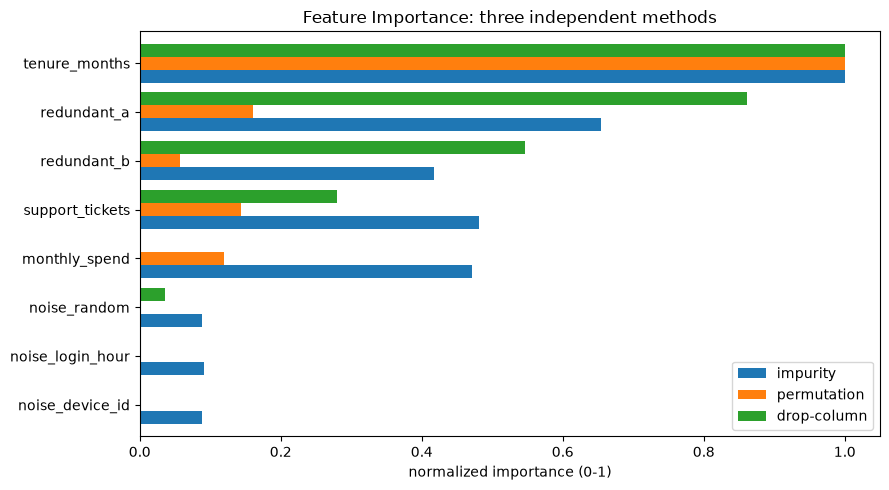

In [7]:
plot_df = out[["impurity_norm", "permutation_norm", "drop_column_norm"]].iloc[::-1]
plot_df.columns = ["impurity", "permutation", "drop-column"]
fig, ax = plt.subplots(figsize=(9, 5))
plot_df.plot.barh(ax=ax, width=0.8)
ax.set_xlabel("normalized importance (0-1)")
ax.set_title("Feature Importance: three independent methods")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Verdict | Meaning | Action |
|---------|---------|--------|
| **trusted** | Top-half by all three methods | Put in front of stakeholders with confidence |
| **noise** | Bottom-half by all three | Safe to drop — simpler, faster model |
| **review** | Methods disagree | Human decision (usually a correlated feature) |

The three planted noise columns land in **noise**. The informative features land in **trusted**. The redundant pair lands in **review** because permutation splits credit between correlated columns while impurity doesn't - which is *exactly* the disagreement a stakeholder needs flagged, not hidden.

## 🔧 Try Your Own

Swap in your own trained model and test set:

In [8]:
# import pandas as pd
# from sklearn.inspection import permutation_importance
#
# my_model = ...        # your fitted estimator
# X_test, y_test = ...  # your held-out data
#
# perm = permutation_importance(my_model, X_test, y_test, n_repeats=10,
#                               random_state=42, scoring="roc_auc")
# import pandas as pd
# pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
#
# For the full three-method verdict, use the reusable module in this repo:
# from importance import train_model, explain

---

Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — a 30-min-a-day FDE portfolio.

**Want the interactive app?** Run `streamlit run app.py` in this folder for a live explorer with the verdict table and consensus chart.